## Loading experiment results

In Mozaik, experiment results are stored in a database called Data Store. In its current implementation, the DataStore is stored as a collection of .pickle files in the results directory of the simulation. It is stored in the following files:

- SegmentX.pickle - Used for storing neural recordings. For each stimulus and each sheet you record from, one Segment is created. So with 2 LGN sheets (ON & OFF cells), and 4 cortical sheets (excitatory and inhibitory cells of Layer 4 and Layer 2/3), 6 Segments are created for each stimulus, as we record some neural activity from all simulated sheets.
- datastore.recordings.pickle - Used for storing references and metadata for the segments. Indispensable for loading the datastore.
- datastore.analysis.pickle - Used for storing analysis results. 
- datastore.sensory.stimulus.pickle - Used for storing the visual stimuli used in experiments. Most of the time almost empty, as we don't store those by default.


Once a simulation has successfully run, you should see all datastore files and at least one Segment in the results directory. If they are not there (especially if you see Segments but no datastore files), the simulation most likely crashed for some reason and needs to be rerun.

In [5]:
%matplotlib inline
from mozaik.storage.datastore import PickledDataStore
from parameters import ParameterSet
from mozaik.storage.queries import param_filter_query
from mozaik.tools.distribution_parametrization import load_parameters
import logging
import sys
from mozaik.storage.queries import *
from mozaik.analysis.analysis import *
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
from mozaik.storage.datastore import DataStoreView
import matplotlib.pyplot as plt
import numpy as np

# Path to the experiment DataStore
# Substitute this path with the path of your own simulation run!
# path = "SelfSustainedPushPull_test_____"
path = "SelfSustainedPushPull_test:fullbig32_0_____"

data_store = PickledDataStore(
    load=True,
    parameters=ParameterSet({"root_directory": path, "store_stimuli": False}),
    replace=False,
)

FileNotFoundError: [Errno 2] No such file or directory: 'SelfSustainedPushPull_test:fullbig32_0_____/datastore.recordings.pickle'

## Datastore contents - LSV1M

If you ran the experiments for the first version of our model (LSV1M), you should see all stimuli (InternalStimulus, FullfieldDriftingSinusoidalGrating, NaturalImageWithEyeMovement, EndOfSimulationBlank) below. Additionally, you can see the analysis results (Analysis Data Structures - ADS) saved into the data store.

In [2]:
data_store.print_content()

INFO:Mozaik:DSV info:
INFO:Mozaik:   Number of recordings: 672
INFO:Mozaik:     InternalStimulus : 288
INFO:Mozaik:     PixelMovieExperanto : 384
INFO:Mozaik:   Number of ADS: 0


In [3]:
dsv = param_filter_query(
        data_store, st_name="PixelMovieExperanto", sheet_name="V1_Exc_L2/3"
    )
dsv.print_content()

INFO:Mozaik:DSV info:
INFO:Mozaik:   Number of recordings: 64
INFO:Mozaik:     PixelMovieExperanto : 64
INFO:Mozaik:   Number of ADS: 0


In [4]:
segs, stims = dsv.get_segments(), dsv.get_stimuli()
bin_size = 1 / 8 * 1000
duration = load_parameters(stims[0])["duration"]
num_trials = load_parameters(data_store.get_experiment_parametrization_list()[0][1])["num_trials"]

spikes_all_stimuli = np.zeros((num_trials, len(segs)//num_trials, len(segs[0].get_spiketrains()), int(np.ceil(duration/bin_size))))
for i in range(spikes_all_stimuli.shape[0]): # Number of trials 
    for j in range(spikes_all_stimuli.shape[1]): # Number of Stimuli
        for k in range(spikes_all_stimuli.shape[2]): # Number of neurons
            spike_times = np.array(segs[i*j].get_spiketrains()[k])
            valid_spikes = spike_times[spike_times < duration]
            spike_indices, counts = np.unique(valid_spikes // bin_size, return_counts=True)
            spikes_all_stimuli[i,j,k,spike_indices.astype(int)] += counts
print(spikes_all_stimuli.shape)

(4, 8, 38150, 17)


In [21]:
i = 1
k = 5
print(segs[i].get_spiketrains()[k])
segs[i].get_spiketrains()[k]

[177.4 468.7] ms


SpikeTrain containing 2 spikes; units ms; datatype float64 
annotations: {'source_population': 'V1_Exc_L2/3',
  'source_id': 170672,
  'source_index': 11,
  'channel_id': 170672}
time: 0.0 ms to 497.0 ms

In [57]:
num_spikes = []
for neuron in range(len(segs[0].get_spiketrains())):
    # print(np.array(segs[i].get_spiketrains()[neuron]))
    a = len(segs[i].get_spiketrains()[neuron])
    num_spikes.append(a)

<BarContainer object of 13 artists>

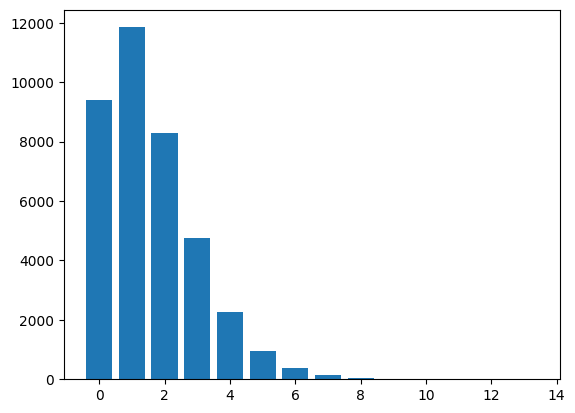

In [66]:
unique, counts = np.unique(num_spikes, return_counts=True)
plt.bar(unique, counts)

In [73]:
np.array(segs[i].get_spiketrains()[4323])

array([ 37. ,  40.7,  97. , 106.2, 109.3, 164.9, 238.5, 254.5, 310.3,
       328.6, 340. , 395.7, 460.8])

In [56]:
(spikes_all_stimuli[0][6] == spikes_all_stimuli[0][0]).all() # ALL the stimuli have the same pattern.

True

In [16]:
load_parameters(stims[0])

{'module_path': 'mozaik.stimuli.vision.topographica_based',
 'background_luminance': 50.0,
 'density': 13.090907186777137,
 'direct_stimulation_name': None,
 'direct_stimulation_parameters': None,
 'duration': 497.0,
 'frame_duration': 7.0,
 'frame_offset': 0,
 'location_x': 0.0,
 'location_y': 0.0,
 'movie_frame_duration': 497.0,
 'movie_name': '00005.npy',
 'movie_path': '/data/dynamic29513-my-test/screen/data',
 'name': 'PixelMovieExperanto',
 'size': 11,
 'size_x': 11.0,
 'size_y': 11.0,
 'trial': 1,
 'video_max_value': 255.0,
 'x_location': 0.0,
 'y_location': 0.0}

In [10]:
len(segs)//num_trials

7

In [17]:
stims[0]

'{"module_path" :"mozaik.stimuli.vision.topographica_based","background_luminance":50.0, "density":13.090907186777137, "direct_stimulation_name":None, "direct_stimulation_parameters":None, "duration":497.0, "frame_duration":7.0, "frame_offset":0, "location_x":0.0, "location_y":0.0, "movie_frame_duration":497.0, "movie_name":\'00011.npy\', "movie_path":\'/data/dynamic29513-my-test/screen/data\', "name":\'PixelMovieExperanto\', "size":11, "size_x":11.0, "size_y":11.0, "trial":0, "video_max_value":255.0, "x_location":0.0, "y_location":0.0}'